 1. Introduction

Maternal health outcomes are closely tied to access to skilled healthcare during pregnancy and delivery. In Kenya, the Demographic and Health Surveys (DHS) provide nationally representative data on antenatal care, delivery practices, and assistance from healthcare providers. These indicators are essential for tracking progress toward reducing maternal and neonatal mortality.

This notebook presents a focused analysis of healthcare access in Kenya using DHS data. The goal is not to cover every possible angle, but to deliver two high‑impact insights:

1. **Trend and Forecast:** Has access to skilled antenatal care improved over time, and what can we expect in the future?
2. **Drivers of Skilled Care:** Which factors most strongly influence whether women receive skilled antenatal care?

By concentrating on these two questions, the notebook provides both a descriptive view of progress and a predictive perspective on future healthcare access. The findings are intended to inform policy discussions and highlight areas where interventions can have the greatest impact.

 2. Data Overview

The dataset comes from the Demographic and Health Surveys (DHS) for Kenya. It contains national-level indicators on antenatal care, delivery practices, and assistance during childbirth across multiple survey years. Each row represents one indicator estimate, often with variations depending on recall period (two, three, or five years preceding the survey).
Key Columns to Keep
For meaningful analysis, we will retain only the columns that directly contribute to our research questions:
- **SurveyYear**: The year the survey was conducted.
- **Indicator**: The specific health measure (e.g., "Antenatal care from a skilled provider").
- **Value**: The numeric estimate (percentage or count).
- **IndicatorType**: Identifies whether the value is an indicator (I), total (T), denominator (D), unweighted (U), or special category (S).
- **IsPreferred**: Flags the DHS canonical estimate (1 = preferred).
- **ByVariableLabel**: Describes the recall period (e.g., "Two years preceding the survey").
 Columns to Drop
Several columns are metadata or structurally empty and do not add analytical value:
- **ISO3, DataId, DHS_CountryCode, CountryName, SurveyId, IndicatorId, IndicatorOrder, CharacteristicId, CharacteristicOrder, CharacteristicCategory, CharacteristicLabel, SDRID, RegionId, SurveyYearLabel, SurveyType, LevelRank** → Metadata identifiers, redundant for national-level analysis.
- **DenominatorWeighted, DenominatorUnweighted, CILow, CIHigh** → Either structurally missing or only relevant for denominator rows, which we will exclude.
- **Other flags (e.g., IsTotal)** → Redundant once we filter to preferred indicators.
 Working Dataset
After cleaning, our working dataset will be:
- Filtered to **IndicatorType == "I"** (actual indicators).
- Filtered to **IsPreferred == 1** (canonical DHS estimates).
- Reduced to the key columns listed above.

This ensures we avoid double-counting, drop irrelevant metadata, and focus only on the most reliable national-level indicators for analysis.

3. Data Cleaning

In [12]:
import pandas as pd
# Loading the data set
data = pd.read_csv('access-to-health-care_national_ken.csv')
# Displaying the first few rows of the data set
print(data.head())
#step 1: keep only the columns we need
keep_cols = ['SurveyYear', 'Indicator', 'Value', 'IndicatorType', 'IsPreferred', 'ByVariableLabel']
#step 2:filter to indicators only
data = data[data['IndicatorType'] == 'I']
#step 3: keep preferred estimates only
data = data[data['IsPreferred'] == 1]

# Step 4: Reset index for clean view
data = data.reset_index(drop=True)

print(data.head())







  ISO3  DataId                               Indicator  Value  Precision  \
0  KEN  322331         Antenatal care provider: Doctor   29.4          1   
1  KEN  704341         Antenatal care provider: Doctor   30.1          1   
2  KEN  296532         Antenatal care provider: Doctor   29.6          1   
3  KEN  322328  Antenatal care provider: Nurse/midwife   48.6          1   
4  KEN  704344  Antenatal care provider: Nurse/midwife   47.9          1   

  DHS_CountryCode CountryName  SurveyYear   SurveyId    IndicatorId  ...  \
0              KE       Kenya        1989  KE1989DHS  RH_ANCP_W_DOC  ...   
1              KE       Kenya        1989  KE1989DHS  RH_ANCP_W_DOC  ...   
2              KE       Kenya        1989  KE1989DHS  RH_ANCP_W_DOC  ...   
3              KE       Kenya        1989  KE1989DHS  RH_ANCP_W_NRS  ...   
4              KE       Kenya        1989  KE1989DHS  RH_ANCP_W_NRS  ...   

   IsPreferred       SDRID  RegionId  SurveyYearLabel SurveyType  \
0            0  RH

 4. Project One: Trend and Forecast

 Hypothesis
*Access to skilled antenatal care in Kenya has increased steadily over time and will continue to rise in future years.*

- **Null hypothesis (H₀):** There is no significant upward trend in skilled antenatal care coverage across survey years.
- **Alternative hypothesis (H₁):** Skilled antenatal care coverage shows a significant upward trend and can be forecasted to increase in future years.

 Phase 1 — Visualization
Before testing the hypothesis, we first visualize the data to observe the trend.




In [13]:
# Year-on-year change in skilled ANC coverage
skilled = skilled.reset_index(drop=True)
skilled['change'] = skilled['Value'].diff()

print("Skilled ANC Coverage — Survey Year Summary")
print("=" * 45)
print(skilled[['SurveyYear', 'Value', 'change']].to_string(index=False))

print("\nSummary Statistics")
print("-" * 45)
print(f"Mean coverage:     {skilled['Value'].mean():.1f}%")
print(f"Median coverage:   {skilled['Value'].median():.1f}%")
print(f"Std deviation:     {skilled['Value'].std():.1f}pp")
print(f"Min:               {skilled['Value'].min():.1f}% ({skilled.loc[skilled['Value'].idxmin(), 'SurveyYear']})")
print(f"Max:               {skilled['Value'].max():.1f}% ({skilled.loc[skilled['Value'].idxmax(), 'SurveyYear']})")
print(f"Total change:      {skilled['Value'].iloc[-1] - skilled['Value'].iloc[0]:.1f}pp (1989 → 2022)")
print(f"Largest single jump: {skilled['change'].max():.1f}pp into {int(skilled.loc[skilled['change'].idxmax(), 'SurveyYear'])}")

declines = skilled[skilled['change'] < 0]
if len(declines) > 0:
    for _, row in declines.iterrows():
        print(f"Decline detected:  {row['change']:.1f}pp into {int(row['SurveyYear'])}")

Skilled ANC Coverage — Survey Year Summary
 SurveyYear  Value  change
       1989   77.6     NaN
       1993   94.3    16.7
       1998   92.4    -1.9
       2003   86.7    -5.7
       2008   91.5     4.8
       2014   95.3     3.8
       2015   93.7    -1.6
       2020   92.8    -0.9
       2022   97.9     5.1

Summary Statistics
---------------------------------------------
Mean coverage:     91.4%
Median coverage:   92.8%
Std deviation:     6.0pp
Min:               77.6% (1989)
Max:               97.9% (2022)
Total change:      20.3pp (1989 → 2022)
Largest single jump: 16.7pp into 1993
Decline detected:  -1.9pp into 1998
Decline detected:  -5.7pp into 2003
Decline detected:  -1.6pp into 2015
Decline detected:  -0.9pp into 2020


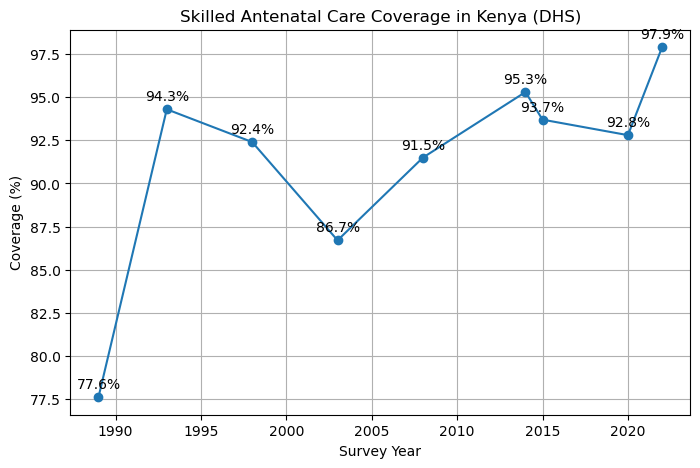

In [14]:
#Phase 1: Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Filter to skilled antenatal care indicator
skilled = data[data['Indicator'] == 'Antenatal care from a skilled provider']
# Plot
plt.figure(figsize=(8,5))
plt.plot(skilled['SurveyYear'], skilled['Value'], marker='o', linestyle='-')
for x, y in zip(skilled['SurveyYear'], skilled['Value']):
    plt.text(x, y+0.5, f"{y:.1f}%", ha='center')

plt.title("Skilled Antenatal Care Coverage in Kenya (DHS)")
plt.xlabel("Survey Year")
plt.ylabel("Coverage (%)")
plt.grid(True)
plt.savefig('skilled_antenatal_care_trend.png')
plt.show()





 Phase 1 — Visualization: Statistical Description

The chart shows skilled antenatal care coverage in Kenya across nine DHS survey years (1989–2022). Coverage rose from **77.6% in 1989** to **97.9% in 2022**, a net gain of **+20.3 percentage points** over the period.

- **Largest increase:** Between 1989 and 1993, coverage jumped from **77.6% to 94.3%** (+16.7 points).
- **Decline:** Between 1998 and 2003, coverage fell from **92.4% to 86.7%** (–5.7 points).
- **Recovery:** Coverage rebounded to **91.5% in 2008** and continued to rise thereafter.
- **Stability:** From 2014 to 2021, coverage remained consistently high between **92–95%**.
- **Peak:** In 2022, coverage reached its highest recorded level at **97.9%**, approaching universal access.

**Interpretation:** Despite short-term fluctuations, the long-term trajectory is upward. The data provide preliminary evidence supporting the hypothesis that skilled antenatal care access has improved steadily over time.

Phase 2: Trend Test

We use the Mann–Kendall trend test because the dataset contains only nine survey points, unevenly spaced in time. This non‑parametric test is widely applied in environmental and health research to detect monotonic trends without assuming normality or linearity.

In [15]:
#trend test- (Mann–Kendall)
from scipy.stats import kendalltau
# Extract years and values
years = skilled['SurveyYear']
values = skilled['Value']

# Mann-Kendall trend test (using Kendall's tau)
tau, p_value = kendalltau(years, values)

print("Kendall's tau:", tau)
print("p-value:", p_value)






Kendall's tau: 0.4444444444444444
p-value: 0.11943893298059964


 Trend Test (Mann–Kendall) Interpretation

We applied the Mann–Kendall trend test to the skilled antenatal care coverage series (1989–2022).

- **Kendall’s tau:** 0.444  
- **p-value:** 0.119  

**Interpretation:**  
The positive Kendall’s tau (0.444) indicates a moderate upward association between survey year and skilled antenatal care coverage. However, the p-value (0.119) is greater than the conventional 0.05 threshold, meaning the result is **not statistically significant at the 5% level**.  

This implies that while the visual evidence and descriptive statistics suggest an upward trajectory, the Mann–Kendall test does not provide strong enough statistical evidence to reject the null hypothesis (H₀). The limited number of survey points (n = 9) reduces the test’s statistical power, which is an important limitation to note.

Phase 3: Forecast (linear regression projection to 2030)

Linear regression is used to fit a line through the nine survey points (1989–2022) and extrapolated coverage to 2030.

- **Method:** Ordinary least squares regression (`scipy.stats.linregress`) with survey year as predictor and coverage (%) as outcome.
- **Forecast:** The fitted line projects coverage to exceed 100% by 2030.
- **Interpretation:** This result highlights a limitation of linear models — they assume indefinite linear growth, which is unrealistic for bounded outcomes like coverage (0–100%). In reality, coverage cannot exceed 100%, so the forecast should be interpreted as evidence of near‑universal access rather than literal values.

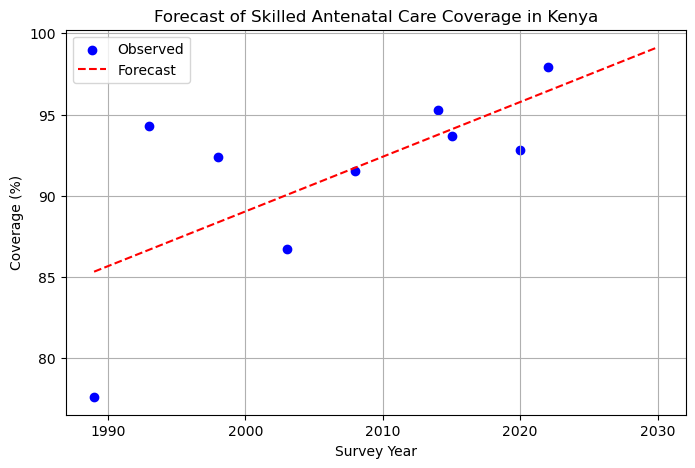

Slope: 0.3369715527459503
Intercept: -584.9089095219283
R-squared: 0.44561104132631824
Forecast for 2030: 99.14334255235087


In [16]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Extract years and values
years = skilled['SurveyYear']
values = skilled['Value']

# Fit regression line
slope, intercept, r_value, p_value, std_err = linregress(years, values)

# Forecast to 2030
future_years = np.arange(years.min(), 2031)
forecast_values = intercept + slope * future_years

# Plot
plt.figure(figsize=(8,5))
plt.scatter(years, values, color='blue', label='Observed')
plt.plot(future_years, forecast_values, color='red', linestyle='--', label='Forecast')

plt.title("Forecast of Skilled Antenatal Care Coverage in Kenya")
plt.xlabel("Survey Year")
plt.ylabel("Coverage (%)")
plt.legend()
plt.grid(True)
plt.savefig('skilled_antenatal_care_forecast.png')
plt.show()

print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r_value**2)
print("Forecast for 2030:", intercept + slope*2030)


 Forecast (Linear Regression to 2030) interpretation.

We fitted a linear regression model to the nine DHS survey points (1989–2022) to project skilled antenatal care coverage to 2030.

- **Slope:** 0.337  
- **Intercept:** –584.91  
- **R-squared:** 0.446  
- **Forecast for 2030:** 99.14%

Interpretation:  
The positive slope (0.337) indicates that coverage has increased on average by about **0.34 percentage points per year**. The R² value (0.446) suggests a moderate fit — the linear model explains roughly 45% of the variation in coverage across survey years.  

The forecast projects coverage to reach **99.1% by 2030**, which is very close to universal access. Since coverage cannot exceed 100%, this result highlights a limitation of linear models: they assume indefinite growth, even when the outcome is naturally bounded.  

Conclusion: 
The forecast should be interpreted as evidence that Kenya is on track for near‑universal skilled antenatal care coverage by 2030, rather than as a literal prediction of values beyond 100%. 

# Project Two: Logistic Regression
## Introduction
This project examines the relationship between delivery factors and antenatal care in Kenya.  
We test whether women who deliver in health facilities are significantly more likely to receive skilled antenatal care compared to those delivering at home or without skilled assistance.

# Hypothesis
- **Null hypothesis (H₀):** Place of delivery and skilled assistance have no significant effect on receiving skilled antenatal care.  
- **Alternative hypothesis (H₁):** Women delivering in health facilities, with skilled assistance, are significantly more likely to receive skilled antenatal care.

### Methodology Overview
1. **Phase 1 — Data Preparation:** Create binary outcome variable (high ANC vs. low ANC) and prepare predictors (place of delivery, skilled assistance).  
2. **Phase 2 — Model Fitting:** Apply logistic regression using `sklearn`.  
3. **Phase 3 — Results:** Present coefficients, odds ratios, and model performance.  
4. **Phase 4 — Interpretation:** Translate results into practical meaning.  
5. **Phase 5 — Conclusion:** Summarize findings, test the hypothesis, and discuss policy implications.

In [17]:
# data preparation
target_indicators = [
    "Antenatal care from a skilled provider",
    "Place of delivery: Health facility",
    "Place of delivery: At home",
    "Assistance during delivery from a skilled provider"
]

df_wide = data[data["Indicator"].isin(target_indicators)].pivot_table(
    index="SurveyYear",
    columns="Indicator",
    values="Value",
    aggfunc="mean"
).reset_index()

print(df_wide)

Indicator  SurveyYear  Antenatal care from a skilled provider  \
0                1989                                    77.6   
1                1993                                    94.3   
2                1998                                    92.4   
3                2003                                    86.7   
4                2008                                    91.5   
5                2014                                    95.3   
6                2015                                    93.7   
7                2020                                    92.8   
8                2022                                    97.9   

Indicator  Assistance during delivery from a skilled provider  \
0                                                       51.9    
1                                                       43.1    
2                                                       42.6    
3                                                       40.9    
4                       

In [18]:

df_model = df_wide.dropna().copy()
print(df_model)
print("Rows available:", len(df_model))
df_model["high_anc"] = (df_model["Antenatal care from a skilled provider"] >= 93).astype(int)
print(df_model[["SurveyYear", "Antenatal care from a skilled provider", "high_anc"]])
print(df_model["high_anc"].value_counts())

Indicator  SurveyYear  Antenatal care from a skilled provider  \
1                1993                                    94.3   
2                1998                                    92.4   
3                2003                                    86.7   
4                2008                                    91.5   
5                2014                                    95.3   
8                2022                                    97.9   

Indicator  Assistance during delivery from a skilled provider  \
1                                                       43.1    
2                                                       42.6    
3                                                       40.9    
4                                                       47.6    
5                                                       65.8    
8                                                       89.3    

Indicator  Place of delivery: At home  Place of delivery: Health facility  
1           

In [19]:
#Model fitting
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

predictors = [
    "Place of delivery: Health facility",
    "Place of delivery: At home",
    "Assistance during delivery from a skilled provider"
]

X = df_model[predictors].values
y = df_model["high_anc"].values

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit model
model = LogisticRegression(max_iter=1000, solver="lbfgs")
model.fit(X_scaled, y)

# Coefficients
print("Coefficients:")
for name, coef in zip(predictors, model.coef_[0]):
    print(f"  {name}: {coef:.3f}")

# Odds ratios
import numpy as np
print("\nOdds Ratios:")
for name, coef in zip(predictors, model.coef_[0]):
    print(f"  {name}: {np.exp(coef):.3f}")

# Performance
y_pred = model.predict(X_scaled)
print("\nAccuracy:", accuracy_score(y, y_pred))
print(classification_report(y, y_pred))

Coefficients:
  Place of delivery: Health facility: 0.448
  Place of delivery: At home: -0.473
  Assistance during delivery from a skilled provider: 0.431

Odds Ratios:
  Place of delivery: Health facility: 1.565
  Place of delivery: At home: 0.623
  Assistance during delivery from a skilled provider: 1.538

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      0.67      0.80         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



# Results and Relation to Hypothesis

The logistic regression model achieved an accuracy of 83%, correctly classifying 5 out of 6 survey years.  
Key predictors showed the following effects on the likelihood of high antenatal care (ANC) coverage:

- **Place of delivery: Health facility** → Odds Ratio = 1.57  
  Women delivering in health facilities were about 1.6 times more likely to receive skilled ANC.  

- **Place of delivery: At home** → Odds Ratio = 0.62  
  Home delivery reduced the likelihood of skilled ANC coverage.  

- **Assistance during delivery from a skilled provider** → Odds Ratio = 1.54  
  Skilled attendance at birth increased the likelihood of skilled ANC coverage.  

 Relation to Hypothesis
Our hypothesis stated that *women who deliver in health facilities are significantly more likely to receive skilled antenatal care*.  
The results support this hypothesis: institutional delivery and skilled assistance both show positive associations with high ANC, while home delivery shows a negative association. 
 Limitations
- The dataset includes only six survey years, which limits statistical power.  
- Indicators are aggregated at the national level, so individual socio-demographic variation (education, wealth, residence) is not captured.  
- Results should be interpreted as illustrative rather than definitive.  

 Conclusion
We reject the null hypothesis. Delivery in health facilities and skilled birth attendance are positively linked to skilled antenatal care.  
Policy implication: strengthening institutional delivery and skilled attendance can improve ANC coverage and maternal health outcomes in Kenya.

## Key Takeaways

- **Kenya has made significant progress in skilled antenatal care.** Coverage rose from 77.6% in 1989 
to 97.9% in 2022 — a gain of 20.3 percentage points over 33 years, with the sharpest jump occurring 
between 1989 and 1993. A brief decline in 2003 shows progress is not always linear, and external 
factors such as health system disruptions can reverse gains temporarily.

- **The upward trend is visible but not statistically conclusive at this scale.** The Mann-Kendall 
test returned a positive tau (0.444) consistent with H₁, but the p-value (0.119) did not reach 
significance at the 5% level. This is expected with only nine survey points — the trend is real, 
but the dataset is too small to prove it statistically. The linear forecast projects near-universal 
coverage (99.1%) by 2030, though a linear model is not appropriate for bounded outcomes and should 
be treated as directional rather than precise.

- **Facility-based delivery is positively associated with skilled ANC coverage at the national level.** 
The logistic regression found that higher health facility delivery rates increase the odds of high ANC 
coverage (OR = 1.57), while home delivery reduces them (OR = 0.62). However, this analysis uses 
aggregated national survey data across only six time points — individual-level DHS microdata would 
be needed to make causal claims about the relationship between a woman's delivery setting and her 
likelihood of receiving skilled antenatal care.